In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
import pysentiment2 as ps
import nltk
from nltk.corpus import stopwords
import numpy as np
import h5py
import numpy as np
import re
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import pandas as pd
import numpy as np
import re
from pathlib import Path
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import re
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

## Construction of the Firm-Level Uncertainty Index

We construct a document-level uncertainty measure based on the frequency of the word stem *“uncertain”* in SEC filings. For each filing $d$, we first identify all occurrences of words matching the regular expression `\buncertain\w*\b`. The raw count of matches is then normalized by document length (total number of whitespace-separated words) to obtain a scaled frequency:

$$\text{UncertaintyScore}_d = \frac{\text{number of uncertainty words in } d}{\text{number of words in } d} \times 10{,}000$$

This yields a measure of uncertainty-related language intensity per 10,000 words.

We then aggregate to the firm-quarter level by taking the simple average of document-level scores across all filings of firm $i$ in quarter $t$:

$$\text{Uncertainty}_{i,t} = \frac{1}{N_{i,t}} \sum_{d \in (i,t)} \text{UncertaintyScore}_d$$

The resulting panel captures variation in the intensity of explicit uncertainty language across firms and time.


In [ ]:
# =====================================================================
# 1. DEFINE REGEX & NORMALIZED CALCULATION
# =====================================================================
print("Compiling regex for Uncertainty terms...")

# Match both "uncertain*" and "uncertainty" explicitly
UNCERTAINTY_REGEX = re.compile(r'\buncertain\w*\b|\buncertainty\b')

def calculate_normalized_uncertainty(text):
    """
    Calculates mentions of uncertainty keywords normalized by document length.
    Returns the count per 10,000 words to make the metric readable.
    """
    if not isinstance(text, str) or not text.strip():
        return 0.0
    
    text_lower = text.lower()
    
    # Count Mentions
    mentions = len(UNCERTAINTY_REGEX.findall(text_lower))
    
    # Count Total Words (simple whitespace split)
    total_words = len(text_lower.split())
    
    if total_words == 0:
        return 0.0
        
    # Normalize: (mentions / total words) * 10,000
    return (mentions / total_words) * 10000

# =====================================================================
# 2. HELPER FUNCTIONS (INSPECTION & PLOTTING)
# =====================================================================
def print_example_sentences(df, n_examples=5):
    print(f"\n--- Extracting {n_examples} Example Matches ---")
    
    # Filter to rows that actually have matches
    sample_rows = df[df['Uncertainty_Score'] > 0]
    
    if sample_rows.empty:
        print("No uncertainty matches found to extract.")
        return
        
    # Take a random sample
    sample_rows = sample_rows.sample(min(n_examples, len(sample_rows)))
    
    for i, (idx, row) in enumerate(sample_rows.iterrows()):
        text = row['Text']
        # Simple sentence tokenizer
        sentences = re.split(r'(?<=[.!?]) +', text)
        
        match_found = False
        for s in sentences:
            if UNCERTAINTY_REGEX.search(s.lower()):
                # Clean up whitespace for printing
                clean_sentence = " ".join(s.split())
                date_str = row['Date'].date() if pd.notnull(row['Date']) else "Unknown Date"
                print(f"\nExample {i+1} (PERMNO {row['PERMNO']}, {date_str}):")
                print(f"> \"...{clean_sentence}...\"")
                match_found = True
                break
                
        if not match_found:
            print(f"\nExample {i+1}: Match detected in row but could not isolate sentence.")

def plot_uncertainty_trends(panel):
    print("\nGenerating Quarterly Trend Plot...")
    
    # Calculate cross-sectional stats for each quarter
    stats = panel.groupby('Quarter')['Uncertainty_Score'].agg(['mean', 'std']).reset_index()
    stats['Quarter_Str'] = stats['Quarter'].astype(str)
    
    plt.figure(figsize=(12, 6))
    plt.plot(stats['Quarter_Str'], stats['mean'], color='tab:blue', lw=2, label='Mean Normalized Uncertainty')
    
    # Shaded Area for Standard Deviation
    plt.fill_between(
        stats['Quarter_Str'], 
        stats['mean'] - stats['std'], 
        stats['mean'] + stats['std'], 
        color='tab:blue', alpha=0.2, label='±1 Std Dev'
    )
    
    plt.title('Quarterly Aggregate Uncertainty Index (Normalized)', fontsize=14)
    plt.xlabel('Quarter')
    plt.ylabel('Uncertainty Words (per 10,000 words)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. PIPELINE FUNCTION FOR FILE 1
# =====================================================================
BASE_DIR = Path(r"C:\Users\jonat\Lasso_paper")

def process_file1_uncertainty(parquet_filename, output_filename):
    parquet_path = BASE_DIR / "Data" / "data_raw" / parquet_filename
    out_path = BASE_DIR / "Data" / "data_raw" / output_filename
    
    print(f"\n{'='*70}")
    print(f"PROCESSING FILE 1: {parquet_filename}")
    print(f"{'='*70}")
    
    # LOAD DATA
    print(f"Loading SEC filings (PERMNO, Date, Text) from: {parquet_path}")
    df_sec = pd.read_parquet(parquet_path, columns=['PERMNO', 'Date', 'Text'])
    print(f"Successfully loaded {len(df_sec)} filings.")

    # CALCULATE NORMALIZED UNCERTAINTY
    print(f"Calculating Normalized Uncertainty Index...")
    df_sec['Uncertainty_Score'] = [
        calculate_normalized_uncertainty(text) 
        for text in tqdm(df_sec['Text'], desc="Processing Text")
    ]

    # FORMAT DATES & AGGREGATE
    print("Formatting dates and aggregating into a quarterly panel...")
    df_sec['Date'] = pd.to_datetime(df_sec['Date'])
    df_sec['Quarter'] = df_sec['Date'].dt.to_period('Q')

    quarterly_panel = (
        df_sec.groupby(['PERMNO', 'Quarter'])['Uncertainty_Score']
        .mean()
        .reset_index()
    )
    
    quarterly_panel = quarterly_panel.sort_values(['PERMNO', 'Quarter'])

    # INSPECT, PRINT EXAMPLES, AND SAVE
    print(f"\n--- Quarterly Index Summary ---")
    print(quarterly_panel['Uncertainty_Score'].describe())

    # Call the print function *before* df_sec is deleted from memory
    print_example_sentences(df_sec, n_examples=5)

    quarterly_panel.to_csv(out_path, index=False)
    print(f"\nSaved File 1 panel to: {out_path}")
    
    return quarterly_panel

# =====================================================================
# 4. EXECUTION
# =====================================================================
if __name__ == "__main__":
    # 1. Run the pipeline to generate the data
    uncertainty_panel_file1 = process_file1_uncertainty(
        parquet_filename="sec_filings_partitioned.parquet", 
        output_filename="firm_level_uncertainty_quarterly.csv"
    )
    

Example 1 (PERMNO 85951, 2010-08-05):
> "...Estimates of fair value are subjective in nature and involve **uncertainties** and matters of significant judgment and, therefore, cannot be determined with precision...."

Example 2 (PERMNO 80381, 2016-02-26):
> "...Many **uncertainties** remain as to the application of these rules, including the application of the alternative method to partners that are REITs, and the impact they will have on us...."

Example 3 (PERMNO 89063, 2014-08-08):
> "...The risks and **uncertainties** inherent in the assessment methodology used to determine declines in market value that are other-than-temporary include, but may not be limited to, the following: • the opinions of professional investment managers could be incorrect; • the past trading patterns of individual investments may not reflect future valuation trends; • the credit ratings assigned by independent credit rating agencies may be incorrect due to unforeseen or unknown facts related to a company's financial situation; and • the debt service pattern of non-investment grade instruments may not reflect future debt service capabilities and may not reflect a company's unknown underlying financial problems...."

Example 4 (PERMNO 43123, 2011-02-28):
> "...Risk Factors There are inherent risks and **uncertainties** associated with our business that could adversely affect our operating performance and financial condition...."

Example 5 (PERMNO 75825, 2010-02-25):
> "...Due to the many **uncertainties** associated with the world political environment, the availabilities of other worldwide energy supplies and the relative competitive relationships of the various energy sources in the view of consumers, EOG is unable to predict what changes may occur in natural gas, crude oil and condensate, natural gas liquids, ammonia and methanol prices in the future...."

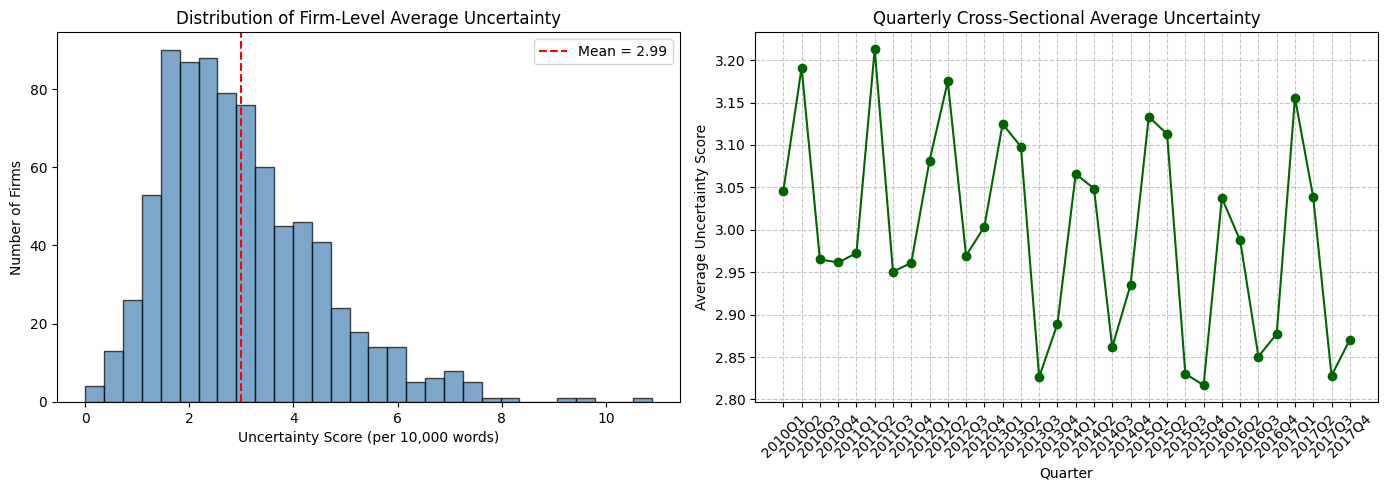

In [10]:
# =====================================================================
# 5. PLOT DISTRIBUTIONS OF UNCERTAINTY INDEX
# =====================================================================
def plot_uncertainty_distributions(quarterly_panel):
    """
    Plot:
    1. Histogram of firm-level average uncertainty (across all quarters)
    2. Time series of quarterly cross-sectional average uncertainty
    """
    # Firm-level averages (mean over quarters for each firm)
    firm_avg = quarterly_panel.groupby('PERMNO')['Uncertainty_Score'].mean()
    
    # Quarterly cross-sectional mean
    quarterly_mean = quarterly_panel.groupby('Quarter')['Uncertainty_Score'].mean().reset_index()
    quarterly_mean['Quarter_Str'] = quarterly_mean['Quarter'].astype(str)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Left: Distribution across firms ---
    ax1.hist(firm_avg, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax1.axvline(firm_avg.mean(), color='red', linestyle='--', 
                label=f'Mean = {firm_avg.mean():.2f}')
    ax1.set_xlabel('Uncertainty Score (per 10,000 words)')
    ax1.set_ylabel('Number of Firms')
    ax1.set_title('Distribution of Firm-Level Average Uncertainty')
    ax1.legend()
    
    # --- Right: Time series of cross-sectional average ---
    ax2.plot(quarterly_mean['Quarter_Str'], quarterly_mean['Uncertainty_Score'],
             marker='o', linestyle='-', color='darkgreen')
    ax2.set_xlabel('Quarter')
    ax2.set_ylabel('Average Uncertainty Score')
    ax2.set_title('Quarterly Cross-Sectional Average Uncertainty')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Call the function after generating the panel
plot_uncertainty_distributions(uncertainty_panel_file1)

In [23]:
import h5py
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =====================================================================
# 1. DATA LOADING AND PREPARATION
# =====================================================================
BASE_DIR = Path(r"C:\Users\jonat\Lasso_paper")
H5_PATH = BASE_DIR / "Results" / "Estimation" / "Cross_Sectional" / "betas.h5"
INDEX_PATH = BASE_DIR / "Data" / "data_raw" / "firm_level_uncertainty_quarterly.csv"

# Load the HDF5 Tensor Data
print(f"Loading tensor data from: {H5_PATH}")
with h5py.File(H5_PATH, 'r') as f:
    betas = f['betas'][:]      # shape: (n_stocks, n_topics, n_dates)
    stocks = f['stocks'][:].astype(str)
    dates = pd.to_datetime(f['dates'][:].astype(str))

# Calculate Daily Selection Rates
print("Calculating daily selection rates from betas...")
is_valid = ~np.isnan(betas)
is_selected = (betas != 0) & is_valid
daily_all_rate = is_selected.sum(axis=1) / np.maximum(is_valid.sum(axis=1), 1)

# Build Panel DataFrame
print("Restructuring tensor into a daily panel format...")
records = []
for i, stock in enumerate(stocks):
    valid_days = is_valid[i, :, :].any(axis=0) 
    if valid_days.any():
        df_stock = pd.DataFrame({
            'PERMNO': str(stock),
            'Date': dates[valid_days],
            'sel_rate_all': daily_all_rate[i, valid_days] 
        })
        records.append(df_stock)

panel_df = pd.concat(records, ignore_index=True)

# Aggregating to Quarterly Frequency
print("Aggregating daily selection rates to quarterly averages...")
panel_df['Quarter'] = panel_df['Date'].dt.to_period('Q')
quarterly_sel = panel_df.groupby(['PERMNO', 'Quarter'])[['sel_rate_all']].mean().reset_index()

# Merge with Consolidated Index Data
print("Merging with uncertainty index...")
indices_df = pd.read_csv(INDEX_PATH)
indices_df['PERMNO'] = indices_df['PERMNO'].astype(str)
indices_df['Quarter'] = pd.PeriodIndex(indices_df['Quarter'], freq='Q')

# Left merge to retain all Lasso firms
reg_df = pd.merge(quarterly_sel, indices_df, on=['PERMNO', 'Quarter'], how='left')

# Sort chronologically to prepare for forward-filling
reg_df = reg_df.sort_values(['PERMNO', 'Quarter'])

# Forward-fill the Uncertainty Index (using 'Uncertainty_Score' from our normalized script)
reg_df['Uncertainty_Score'] = reg_df.groupby('PERMNO')['Uncertainty_Score'].ffill(limit=3)

# Finalize index for the regressions
reg_df['Quarter'] = reg_df['Quarter'].dt.to_timestamp()
reg_df = reg_df.set_index(['PERMNO', 'Quarter'])

# Drop missing values to ensure clean regression matrices
clean_reg_df = reg_df.dropna(subset=['sel_rate_all', 'Uncertainty_Score']).copy()

# =====================================================================
# 1.5 SUMMARY STATISTICS FOR sel_rate_all
# =====================================================================
print("\n" + "="*70)
print("SUMMARY STATISTICS: sel_rate_all")
print("="*70)
# Using describe() to get standard summary metrics
summary_stats = clean_reg_df['sel_rate_all'].describe()
print(summary_stats)

# Optional: Add Skewness and Kurtosis for deeper analysis
print(f"\nSkewness: {clean_reg_df['sel_rate_all'].skew():.4f}")
print(f"Kurtosis: {clean_reg_df['sel_rate_all'].kurt():.4f}")
print("="*70 + "\n")

# =====================================================================
# 2. STANDARDIZE UNCERTAINTY INDEX WITHIN EACH QUARTER (Z-SCORE)
# =====================================================================
print("\nStandardizing Uncertainty_Score within each quarter...")
# Reset index temporarily to have Quarter as a column
temp_df = clean_reg_df.reset_index()
# Compute quarterly mean and std
quarterly_stats = temp_df.groupby('Quarter')['Uncertainty_Score'].agg(['mean', 'std']).rename(columns={'mean': 'q_mean', 'std': 'q_std'})
temp_df = temp_df.join(quarterly_stats, on='Quarter')
# Standardize: (x - mean) / std
temp_df['Uncertainty_Std'] = (temp_df['Uncertainty_Score'] - temp_df['q_mean']) / temp_df['q_std']
# Drop helper columns and set index back
temp_df = temp_df.drop(columns=['q_mean', 'q_std'])
clean_reg_df = temp_df.set_index(['PERMNO', 'Quarter'])
print(f"Standardized uncertainty index. Mean ~0, Std ~1 by construction (within quarter).")

# =====================================================================
# 3. CROSS-SECTIONAL REGRESSION (Between Effects)
# =====================================================================
print("\n" + "="*70)
print("RUNNING CROSS-SECTIONAL REGRESSION (using standardized uncertainty)")
print("="*70)

# Collapse the panel to firm-level averages of the standardized variable
cross_df = clean_reg_df.groupby('PERMNO')[['sel_rate_all', 'Uncertainty_Std']].mean()

Y_cs = cross_df['sel_rate_all']
X_cs = sm.add_constant(cross_df['Uncertainty_Std'])

model_cs = sm.OLS(Y_cs, X_cs).fit()
print(model_cs.summary())

# =====================================================================
# 4. PANEL REGRESSION (Two-Way Fixed Effects)
# =====================================================================
print("\n" + "="*70)
print("RUNNING PANEL REGRESSION (FIRM & TIME FIXED EFFECTS, standardized uncertainty)")
print("="*70)

Y_panel = clean_reg_df['sel_rate_all']
X_panel = sm.add_constant(clean_reg_df['Uncertainty_Std'])

try:
    model_panel = PanelOLS(
        Y_panel, 
        X_panel, 
        entity_effects=False,   # Firm fixed effects
        time_effects=True      # Quarter fixed effects
    ).fit(cov_type='clustered', cluster_entity=True)
    
    print(model_panel.summary)
except Exception as e:
    print(f"Panel Regression failed. Error: {e}")

Loading tensor data from: C:\Users\jonat\Lasso_paper\Results\Estimation\Cross_Sectional\betas.h5
Calculating daily selection rates from betas...
Restructuring tensor into a daily panel format...
Aggregating daily selection rates to quarterly averages...
Merging with uncertainty index...

SUMMARY STATISTICS: sel_rate_all
count    21527.000000
mean         0.022760
std          0.044508
min          0.000000
25%          0.000000
50%          0.003125
75%          0.024674
max          0.601188
Name: sel_rate_all, dtype: float64

Skewness: 3.4556
Kurtosis: 16.5499


Standardizing Uncertainty_Score within each quarter...
Standardized uncertainty index. Mean ~0, Std ~1 by construction (within quarter).

RUNNING CROSS-SECTIONAL REGRESSION (using standardized uncertainty)
                            OLS Regression Results                            
Dep. Variable:           sel_rate_all   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:          

In [25]:
# =====================================================================
# 2.5 LOG TRANSFORM AND STANDARDIZE UNCERTAINTY
# =====================================================================
print("\nApplying Log-transformation and standardizing within each quarter...")

# Apply log1p: ln(1 + x)
clean_reg_df['Uncertainty_Log'] = np.log1p(clean_reg_df['Uncertainty_Score'])

# Standardize the Log-transformed version
temp_df = clean_reg_df.reset_index()
log_stats = temp_df.groupby('Quarter')['Uncertainty_Log'].agg(['mean', 'std']).rename(columns={'mean': 'l_mean', 'std': 'l_std'})
temp_df = temp_df.join(log_stats, on='Quarter')

# Standardize: (log_x - mean_log_x) / std_log_x
temp_df['Uncertainty_Log_Std'] = (temp_df['Uncertainty_Log'] - temp_df['l_mean']) / temp_df['l_std']
clean_reg_df = temp_df.drop(columns=['l_mean', 'l_std']).set_index(['PERMNO', 'Quarter'])

# =====================================================================
# 3. CROSS-SECTIONAL REGRESSION (Log-Transformed)
# =====================================================================
print("\n" + "="*70)
print("RUNNING CROSS-SECTIONAL REGRESSION (Log-transformed uncertainty)")
print("="*70)

cross_df_log = clean_reg_df.groupby('PERMNO')[['sel_rate_all', 'Uncertainty_Log_Std']].mean()
Y_cs = cross_df_log['sel_rate_all']
X_cs_log = sm.add_constant(cross_df_log['Uncertainty_Log_Std'])

model_cs_log = sm.OLS(Y_cs, X_cs_log).fit()
print(model_cs_log.summary())

# =====================================================================
# 4. PANEL REGRESSION (Log-Transformed)
# =====================================================================
print("\n" + "="*70)
print("RUNNING PANEL REGRESSION (FIRM & TIME EFFECTS, Log-transformed uncertainty)")
print("="*70)

Y_panel = clean_reg_df['sel_rate_all']
X_panel_log = sm.add_constant(clean_reg_df['Uncertainty_Log_Std'])

try:
    model_panel_log = PanelOLS(
        Y_panel, 
        X_panel_log, 
        entity_effects=True,   # Re-enabled to properly control for firm characteristics
        time_effects=True      
    ).fit(cov_type='clustered', cluster_entity=True)
    
    print(model_panel_log.summary)
except Exception as e:
    print(f"Panel Regression failed. Error: {e}")


Applying Log-transformation and standardizing within each quarter...

RUNNING CROSS-SECTIONAL REGRESSION (Log-transformed uncertainty)
                            OLS Regression Results                            
Dep. Variable:           sel_rate_all   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     8.468
Date:                Tue, 19 May 2026   Prob (F-statistic):            0.00371
Time:                        18:26:30   Log-Likelihood:                 1678.8
No. Observations:                 806   AIC:                            -3354.
Df Residuals:                     804   BIC:                            -3344.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.02

Interpretation: A one sd higher uncertainty index is associated with a 0.33 percentage points higher selection rate in the cross section and a 0.14 pp higher selection rate in the panel model. Reduction of effect size suggests that this is to a great extent driven by differences between firms. Thus, the next cell controls for industry fixed effects.

In [26]:
# [Cell: Fetch and Clean Industry Data from WRDS]
import wrds
import pandas as pd

# 1. Establish Connection (requires WRDS credentials)
db = wrds.Connection()

# 2. Pull SIC codes
sql_query = """
SELECT permno, siccd, nameenddt
FROM crsp.stocknames
WHERE siccd IS NOT NULL
"""
crsp_ind_raw = db.raw_sql(sql_query)

# 3. Process the latest industry code per firm
crsp_ind_raw['permno'] = crsp_ind_raw['permno'].astype(float)
crsp_ind_raw['nameenddt'] = pd.to_datetime(crsp_ind_raw['nameenddt'])

crsp_ind = (
    crsp_ind_raw
    .sort_values(['permno', 'nameenddt'])
    .groupby('permno')
    .tail(1)
    .reset_index(drop=True)
)
crsp_ind.columns = ['permno', 'siccd', 'last_date']
print(f"Successfully loaded industry data for {len(crsp_ind)} unique PERMNOs.")

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\jonat\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Successfully loaded industry data for 38872 unique PERMNOs.


In [16]:
# [Cell: Define Fama-French 12 Industry Mapping Function]
def get_ff12_name(sic):
    """
    Maps SIC codes to Fama-French 12 industry classifications.
    Required for testing 'Investor Association' across sectors.
    """
    try:
        s = int(sic)
    except:
        return 'Other'
    if 100 <= s <= 999: return 'Agri'
    if 1000 <= s <= 1499: return 'Mine'
    if 1500 <= s <= 1799: return 'Cons'
    if 2000 <= s <= 3999:
        if 2000 <= s <= 2399 or 2700 <= s <= 2799 or 3100 <= s <= 3199: return 'NoDur'
        if 2400 <= s <= 2599 or 3000 <= s <= 3099 or 3200 <= s <= 3569 or 3580 <= s <= 3699 or 3800 <= s <= 3999: return 'Durbl'
        if 2600 <= s <= 2699 or 2800 <= s <= 2999: return 'Chems'
        if 3570 <= s <= 3579 or 3670 <= s <= 3679: return 'BusEq'
        if 3700 <= s <= 3799: return 'Manuf'
    if 4000 <= s <= 4899: return 'Trans'
    if 4900 <= s <= 4949: return 'Utils'
    if 5000 <= s <= 5999: return 'Shops'
    if 6000 <= s <= 6999: return 'Money'
    return 'Other'

In [29]:
# =====================================================================
# CELL: ESTIMATE MODELS WITH INDUSTRY FIXED EFFECTS (Fama-French 12)
# =====================================================================

# --- 1. Ensure clean_reg_df is available (from previous cells) ---
# If clean_reg_df is not in memory, you may need to re-run earlier cells.
# Here we assume clean_reg_df already exists with PERMNO, Quarter, sel_rate_all, Uncertainty_Std.

# --- 2. Merge industry classification ---
print("Merging industry classification...")

# Make a copy of clean_reg_df as a DataFrame (reset index) for merging
reg_df_merged = clean_reg_df.reset_index()

# Convert PERMNO to numeric for merging (if it's stored as string)
reg_df_merged['PERMNO_num'] = reg_df_merged['PERMNO'].astype(float)

# Merge with the crsp_ind data (which has 'permno' and 'siccd')
# Use left join to keep all regression observations
reg_df_merged = reg_df_merged.merge(
    crsp_ind[['permno', 'siccd']], 
    left_on='PERMNO_num', 
    right_on='permno', 
    how='left'
)

# Apply the FF12 mapping function to the SIC code
reg_df_merged['Industry_FF12'] = reg_df_merged['siccd'].apply(get_ff12_name)

# Drop observations with missing industry (should be few)
reg_df_merged = reg_df_merged.dropna(subset=['Industry_FF12'])

# Create industry dummies (exclude one category as reference)
industry_dummies = pd.get_dummies(reg_df_merged['Industry_FF12'], prefix='IND', drop_first=True)
# Convert to integer (0/1) to avoid object dtype issues
industry_dummies = industry_dummies.astype(int)
reg_df_merged = pd.concat([reg_df_merged, industry_dummies], axis=1)

print(f"Industry distribution:\n{reg_df_merged['Industry_FF12'].value_counts()}")

# Set back to MultiIndex for panel (optional for cross-section)
reg_df_industry = reg_df_merged.set_index(['PERMNO', 'Quarter'])

# --- 3. CROSS-SECTIONAL REGRESSION (Industry Fixed Effects) ---
print("\n" + "="*70)
print("CROSS-SECTIONAL REGRESSION (Firm-level averages with industry FE)")
print("="*70)

# Collapse to firm-level averages (keeping industry dummies per firm – they are constant over time)
agg_dict = {
    'sel_rate_all': 'mean',
    'Uncertainty_Std': 'mean',
}
# Add industry dummies: take first value (constant per firm)
for col in industry_dummies.columns:
    agg_dict[col] = 'first'

cross_df_ind = reg_df_merged.groupby('PERMNO').agg(agg_dict)

# Ensure all dummy columns are numeric (in case 'first' retained booleans)
for col in industry_dummies.columns:
    cross_df_ind[col] = pd.to_numeric(cross_df_ind[col], errors='coerce')

# Drop any rows with missing values in the independent variables (if any)
cross_df_ind = cross_df_ind.dropna(subset=['Uncertainty_Std'] + list(industry_dummies.columns))

Y_cs_ind = cross_df_ind['sel_rate_all']
X_cs_ind_cols = ['Uncertainty_Std'] + list(industry_dummies.columns)
X_cs_ind = sm.add_constant(cross_df_ind[X_cs_ind_cols])

# Verify all X columns are numeric
print("Checking data types in X_cs_ind:\n", X_cs_ind.dtypes.value_counts())

model_cs_ind = sm.OLS(Y_cs_ind, X_cs_ind).fit()
print(model_cs_ind.summary())

# --- 4. PANEL REGRESSION (Industry + Time Fixed Effects) ---
print("\n" + "="*70)
print("PANEL REGRESSION (Industry and Time Fixed Effects, no firm FE)")
print("="*70)

# Prepare panel data: Y and X include industry dummies and time dummies (time_effects=True in PanelOLS)
Y_panel_ind = reg_df_industry['sel_rate_all']

# X includes Uncertainty_Std and the industry dummies (time-invariant)
X_panel_ind = reg_df_industry[['Uncertainty_Std'] + list(industry_dummies.columns)]
# Ensure no missing values
X_panel_ind = X_panel_ind.dropna()
Y_panel_ind = Y_panel_ind.loc[X_panel_ind.index]  # align

X_panel_ind = sm.add_constant(X_panel_ind)

try:
    # Use time_effects=True to absorb common time shocks
    # entity_effects=False because industry dummies already capture industry-level time-invariant heterogeneity
    model_panel_ind = PanelOLS(
        Y_panel_ind,
        X_panel_ind,
        entity_effects=False,
        time_effects=True
    ).fit(cov_type='clustered', cluster_entity=True)  # cluster at firm level
    
    print(model_panel_ind.summary)
except Exception as e:
    print(f"Panel regression with industry FE failed: {e}")

Merging industry classification...
Industry distribution:
Industry_FF12
Money    5622
Durbl    3348
Other    2521
Shops    2190
Chems    1629
Mine     1325
NoDur    1323
Utils    1134
Manuf     918
Trans     734
Cons      567
BusEq     189
Agri       27
Name: count, dtype: int64

CROSS-SECTIONAL REGRESSION (Firm-level averages with industry FE)
Checking data types in X_cs_ind:
 int64      12
float64     2
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:           sel_rate_all   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     10.89
Date:                Tue, 19 May 2026   Prob (F-statistic):           1.25e-21
Time:                        18:34:17   Log-Likelihood:                 1740.8
No. Observations:                 806   AIC:                            -3454.
Df Residuals

In [30]:
# 1. Quick check: What columns DO we actually have?
print("Available columns in crsp_ind:", crsp_ind.columns.tolist())

# 2. Get the sets of PERMNOs (ensure both are strings for a clean set difference)
permnos_in_tensor = set(stocks)
permnos_in_index = set(indices_df['PERMNO'].astype(str).unique())
missing_from_index = permnos_in_tensor - permnos_in_index

print(f"\n--- GAP ANALYSIS ---")
print(f"Firms missing uncertainty data: {len(missing_from_index)}")

# 3. Find which columns are available for the merge
possible_name_cols = [c for c in ['comnam', 'conm', 'company_name'] if c in crsp_ind.columns]
possible_sic_cols = [c for c in ['siccd', 'sic', 'SIC'] if c in crsp_ind.columns]
cols_to_use = ['permno'] + possible_name_cols + possible_sic_cols

# 4. Create the DataFrame and FIX DATA TYPE
missing_df = pd.DataFrame(list(missing_from_index), columns=['PERMNO'])

# Cast to float to match crsp_ind exactly
missing_df['PERMNO'] = missing_df['PERMNO'].astype(float) 

# Perform the merge
missing_df = pd.merge(missing_df, crsp_ind[cols_to_use], 
                      left_on='PERMNO', right_on='permno', how='left')

# 5. Apply the FF12 mapping
if possible_sic_cols:
    sic_col = possible_sic_cols[0]
    # We use the function from your earlier environment
    missing_df['Industry'] = missing_df[sic_col].apply(get_ff12_name)
    
    print("\n--- EXAMPLES OF MISSING FIRMS ---")
    print(missing_df.head(15))
    
    print("\n--- COUNT OF MISSING FIRMS BY INDUSTRY ---")
    print(missing_df['Industry'].value_counts())
else:
    print("\nCould not find a SIC column to determine industry.")

Available columns in crsp_ind: ['permno', 'siccd', 'last_date']

--- GAP ANALYSIS ---
Firms missing uncertainty data: 489

--- EXAMPLES OF MISSING FIRMS ---
     PERMNO   permno  siccd Industry
0   89256.0  89256.0   6719    Money
1   87444.0  87444.0   3842    Durbl
2   90160.0  90160.0   8062    Other
3   86754.0  86754.0   6722    Money
4   84661.0  84661.0   2086    NoDur
5   86121.0  86121.0   2259    NoDur
6   93026.0  93026.0   6722    Money
7   77309.0  77309.0   6722    Money
8   89462.0  89462.0   3699    Durbl
9   77920.0  77920.0   6082    Money
10  85237.0  85237.0   4911    Utils
11  87356.0  87356.0   7812    Other
12  90499.0  90499.0   6722    Money
13  77928.0  77928.0   2082    NoDur
14  86486.0  86486.0   6726    Money

--- COUNT OF MISSING FIRMS BY INDUSTRY ---
Industry
Money    304
Trans     40
Mine      38
Durbl     24
Other     24
NoDur     20
Utils     12
Chems     10
Shops      8
Manuf      6
Cons       1
Agri       1
BusEq      1
Name: count, dtype: int64


Open Questions:

How to handle funds and etfs in our data?
How to handle utlities sector?
REITS?